In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

In [2]:
plt.rcParams['font.family'] ='sans-serif'
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6.0
plt.rcParams['ytick.major.size'] = 6.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.minor.size'] = 4.0
plt.rcParams['ytick.minor.size'] = 4.0
plt.rcParams['xtick.minor.width'] = 0.8
plt.rcParams['ytick.minor.width'] = 0.8
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['font.size'] = 20
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['text.usetex'] = False

In [3]:
import ps_1loop

## Gaussian initial condition

In [4]:
model = ps_1loop.PowerSpectrum1Loop()

In [5]:
## Set the linear matter power spectrum at z=0
d = np.loadtxt('data/pk_lin_planck18_fid_z0.txt')
k, pk_lin = d[:,0], d[:,1]
model.set_pk_lin(k, pk_lin)

## Preparation for computing 1-loop terms
model.set_1loop(hubble=0.6736)

In [6]:
## Set the linear growth factor D (normalized as D(z=0)=1) and the linear growth rate f. 
## Here, we want to compute the galaxy power spectrum at z=1 in Planck 2018 cosmology.
model.set_Dgrowth(Dgrowth=0.6067)
model.set_fgrowth(fgrowth=0.8768)

## Set galaxy bias parameters
bias = {'b1':2., 'b2':-1., 'bG2':0.1, 'bGamma3':-0.1}
model.set_bias_params(bias)

## Set EFT counterterm parameters
ctr = {'c0':5., 'c2':15., 'c4':-5., 'cfog':100.}
model.set_ctr_params(ctr)

## Set stochasticity parameters
stoch = {'P_shot':0., 'a0':0., 'a2':0.} # means no stochasticity
model.set_stoch_params(stoch=stoch, ndens=3e-4, k_nl=0.45)

In [7]:
## Output P(k,mu) as numpy array of shape (len(k), len(mu))
k = np.linspace(1e-3,0.3,100)
mu = np.linspace(0,1,10)
pkmu = model.get_pkmu_gg(k, mu, irres=True)

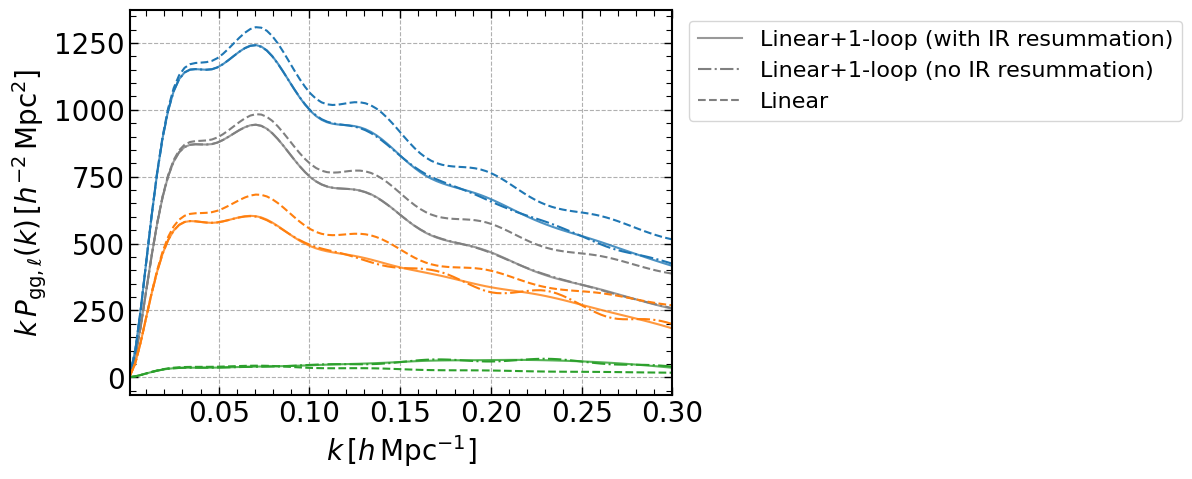

In [8]:
## Plot P_ell(k)

fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

k = np.linspace(1e-3, 0.3, 100)

# real space
pk_tree = model.get_pk_gg_lin(k)
pk_noirres = model.get_pk_gg(k, irres=False)
pk_irres = model.get_pk_gg(k, irres=True)
ax.plot(k, k * pk_irres, ls='-', c='gray', alpha=0.8, label=r'Linear+1-loop (with IR resummation)')
ax.plot(k, k * pk_noirres, ls='-.', c='gray', label=r'Linear+1-loop (no IR resummation)')
ax.plot(k, k * pk_tree, ls='--', c='gray', label=r'Linear')

ells = [0,2,4]
pkl_tree = model.get_pk_ell_gg_lin(k, ells)
pkl_noirres = model.get_pk_ell_gg(k, ells, irres=False)
pkl_irres = model.get_pk_ell_gg(k, ells, irres=True)

# redshift space multipoles
for i, l in enumerate([0,2,4]):
    ax.plot(k, k * pkl_irres[i], ls='-', c=color[i], alpha=0.8,)
    ax.plot(k, k * pkl_noirres[i], ls='-.', c=color[i])
    ax.plot(k, k * pkl_tree[i], ls='--', c=color[i])
    
axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h\,\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k \, P_{\mathrm{gg},\ell}(k)\,[h^{-2}\,\mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.legend(fontsize=16, bbox_to_anchor=(1.01, 1.0), loc='upper left')
    plt.grid(linestyle='--')

### Alcock-Pacynski effect

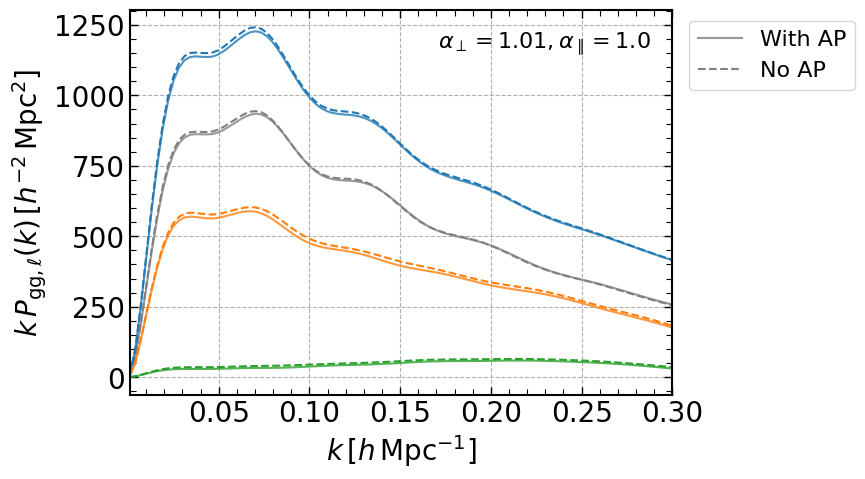

In [9]:
## Plot P_ell(k) with AP effect

fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

k = np.linspace(1e-3,0.3,100)

# AP parameters, depending on the reference cosmology and redshift
alpha_perp = 1.01
alpha_para = 1.

# real space
pk_AP = model.get_pk_gg_ref(k, alpha_perp, alpha_para, irres=True)
pk = model.get_pk_gg(k, irres=True)
ax.plot(k, k * pk_AP, ls='-', c='gray', alpha=0.8, label=r'With AP')
ax.plot(k, k * pk, ls='--', c='gray', label=r'No AP')

ells = [0,2,4]
pkl_AP = model.get_pk_ell_gg_ref(k, ells, alpha_perp, alpha_para, irres=True)
pkl = model.get_pk_ell_gg(k, ells, irres=True)

# redshift space multipoles
for i, l in enumerate(ells):
    ax.plot(k, k * pkl_AP[i], ls='-', c=color[i], alpha=0.8)
    ax.plot(k, k * pkl[i], ls='--', c=color[i])
    
ax.text(0.96, 0.9, r'$\alpha_\perp=%s, \alpha_\parallel=%s$' % (alpha_perp, alpha_para), fontsize=16, transform=ax.transAxes, ha='right')
    
axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h\,\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k \, P_{\mathrm{gg},\ell}(k)\,[h^{-2}\,\mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.legend(fontsize=16, bbox_to_anchor=(1.01, 1.0), loc='upper left')
    plt.grid(linestyle='--')

## Local primordial non-Gaussianity

In [10]:
model = ps_1loop.PowerSpectrum1LoopLPNG()

In [11]:
## Set the linear matter power spectrum and transfer function M(k) for PNG at z=0
d = np.loadtxt('data/pk_lin_planck18_fid_z0.txt')
k, pk_lin = d[:,0], d[:,1]
model.set_pk_lin(k, pk_lin)

d = np.loadtxt('data/Mk_planck18_fid_z0.txt')
k, Mk = d[:,0], d[:,1]
model.set_Mk(k, Mk)

## Preparation for computing 1-loop terms
model.set_1loop(hubble=0.6736)

In [12]:
## Set the linear growth factor D (normalized as D(z=0)=1) and the linear growth rate f. 
## Here, we want to compute the galaxy power spectrum at z=1 in Planck 2018 cosmology.
model.set_Dgrowth(Dgrowth=0.6067)
model.set_fgrowth(fgrowth=0.8768)

## Set f_NL
f_nl = 10.
model.set_f_nl(f_nl)

## Set bias parameters
bias = {'b1':2., 'b2':-1., 'bG2':0.1, 'bGamma3':-0.1, 'bphi':5., 'bphid':10.}
model.set_bias_params(bias)

## Set EFT counterterm parameters
ctr = {'c0':5., 'c2':15., 'c4':-5., 'cfog':100.}
model.set_ctr_params(ctr)

## Set stochasticity parameters
stoch = {'P_shot':0., 'a0':0., 'a2':0.} # means no stochasticity
model.set_stoch_params(stoch=stoch, ndens=3e-4, k_nl=0.45)

In [13]:
## Output P(k,mu) as numpy array of shape (len(k), len(mu))
k = np.linspace(1e-3,0.3,100)
mu = np.linspace(0,1,10)
pkmu = model.get_pkmu_gg(k, mu, irres=True)

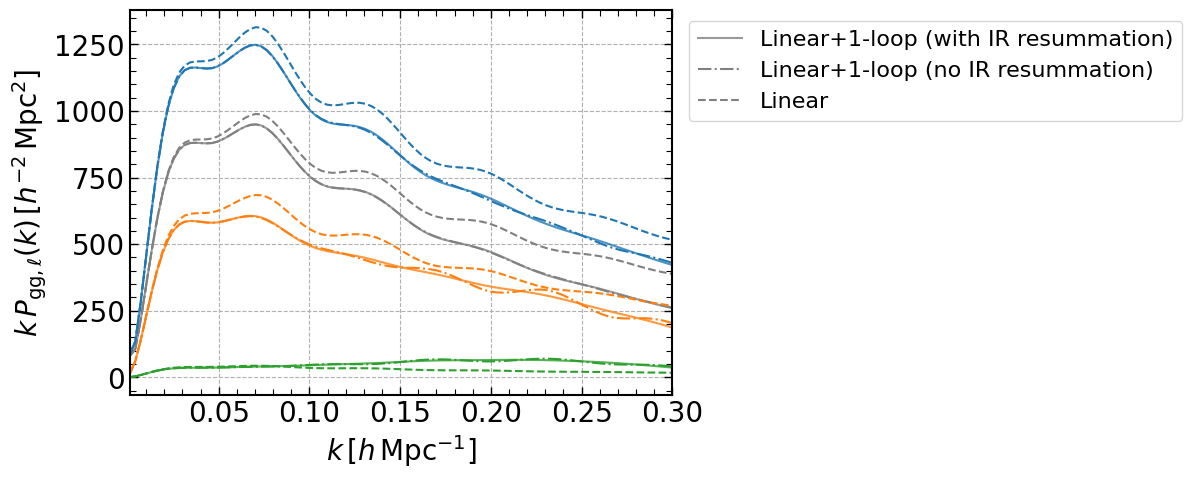

In [14]:
## Plot P_ell(k)

fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']
ax = fig.add_subplot()

k = np.linspace(1e-3,0.3,100)

# real space
pk_tree = model.get_pk_gg_lin(k)
pk_noirres = model.get_pk_gg(k, irres=False)
pk_irres = model.get_pk_gg(k, irres=True)
ax.plot(k, k * pk_irres, ls='-', c='gray', alpha=0.8, label=r'Linear+1-loop (with IR resummation)')
ax.plot(k, k * pk_noirres, ls='-.', c='gray', label=r'Linear+1-loop (no IR resummation)')
ax.plot(k, k * pk_tree, ls='--', c='gray', label=r'Linear')

ells = [0,2,4]
pkl_tree = model.get_pk_ell_gg_lin(k, ells)
pkl_noirres = model.get_pk_ell_gg(k, ells, irres=False)
pkl_irres = model.get_pk_ell_gg(k, ells, irres=True)

# redshift space multipoles
for i, l in enumerate([0,2,4]):
    ax.plot(k, k * pkl_irres[i], ls='-', c=color[i], alpha=0.8,)
    ax.plot(k, k * pkl_noirres[i], ls='-.', c=color[i])
    ax.plot(k, k * pkl_tree[i], ls='--', c=color[i])
    
axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k \, [h\,\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k \, P_{\mathrm{gg},\ell}(k)\,[h^{-2}\,\mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.legend(fontsize=16, bbox_to_anchor=(1.01, 1.0), loc='upper left')
    plt.grid(linestyle='--')

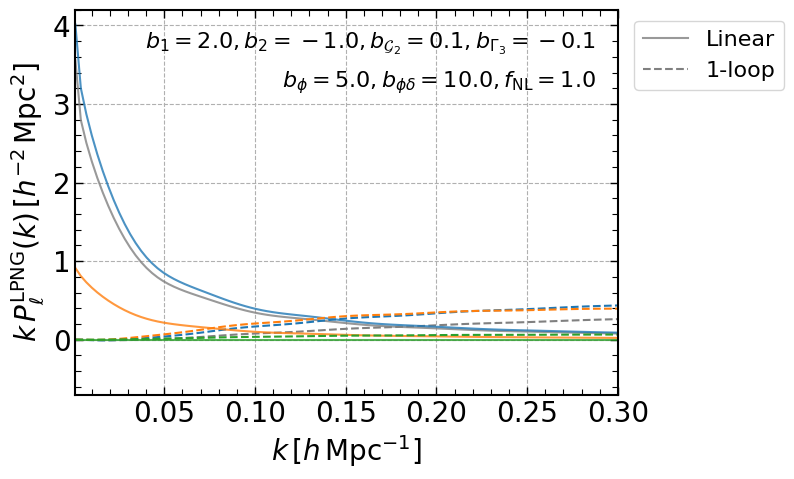

In [15]:
## Plot local PNG contributions of P_ell(k)

fig = plt.figure(figsize=(7,5))
color = plt.rcParams['axes.prop_cycle'].by_key()['color']

ax = fig.add_subplot()

f_nl = 1.
model.set_f_nl(f_nl=f_nl)

k = np.linspace(1e-3,0.3,100)

# real space
model.set_f_nl(f_nl)
pk_png_tree = model.get_pk_gg_lin(k)
model.set_f_nl(0)
pk_tree = model.get_pk_gg_lin(k)
ax.plot(k, k * (pk_png_tree - pk_tree), ls='-', c='gray', alpha=0.8, label=r'Linear')
model.set_f_nl(f_nl)
pk_png_1loop = model.get_pkmu_gg_1loop(k, 0, name='lpng_tot')
ax.plot(k, k * pk_png_1loop, ls='--', c='gray', label=r'1-loop')

ells = [0,2,4]
model.set_f_nl(f_nl)
pl_png_tree = model.get_pk_ell_gg_lin(k, ells)
model.set_f_nl(0)
pl_tree = model.get_pk_ell_gg_lin(k, ells)
model.set_f_nl(f_nl)
pl_png_1loop = model.get_pk_ell_gg_1loop(k, ells, name='lpng_tot')

# Redshift-space multipoles
for i, l in enumerate(ells):
    ax.plot(k, k * (pl_png_tree - pl_tree)[i], ls='-', c=color[i], alpha=0.8)
    ax.plot(k, k * pl_png_1loop[i], ls='--', c=color[i], alpha=1)

ax.text(0.96, 0.9, r'$b_1=%s, b_2=%s, b_{\mathcal{G}_2}=%s, b_{\Gamma_3}=%s$' % (bias['b1'], bias['b2'], bias['bG2'], bias['bGamma3']), fontsize=16, transform=ax.transAxes, ha='right')
ax.text(0.96, 0.8, r'$b_{\phi}=%s, b_{\phi\delta}=%s, f_\mathrm{NL}=%s$' % (bias['bphi'], bias['bphid'], model.f_nl), fontsize=16, transform=ax.transAxes, ha='right')
ax.legend(fontsize=16, bbox_to_anchor=(1.01, 1.0), loc='upper left')

axs = plt.gcf().get_axes()
for ax in axs:
    plt.sca(ax)
    plt.xlabel(r'$k\,[h\,\mathrm{Mpc}^{-1}]$')
    plt.ylabel(r'$k\,P_{\ell}^\mathrm{LPNG}(k)\,[h^{-2}\,\mathrm{Mpc}^2]$')
    plt.xlim(k.min(), k.max())
    plt.ylim(-0.7,4.2)
    plt.grid(linestyle='--')